##### RA5, MANDATORIES EXERCISES
AUTHOR: David Cueli<br>
DATE: 2025-06-03<br>
DESCRIPTION: This notebook contains the mandatory exercises for RA5 step by step<br>

##### KDD PHASES:
- Data selection.
- Data cleaning.
- Data transformation.
- Data mining.
- Interpretation and evaluation.

In [18]:
import time
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

totInitTime = time.time()
qtyDataPreviews = 3

In [19]:
def LBr(pHowMany: int = 1, pComm: str = ""):
  if pComm:
    print(f"+ ")
    print(f"+ {pComm}")

  for i in range(0, pHowMany):
    print(f"+ ")

def Bra(pHowMany: int = 0, pTitle: str = ""):
  LBr(pHowMany)
  if pTitle:
    print(f"+ {pTitle}")
    
  print(f"+ --------------------------------------------------------------------------------------------------------------------------------------")

def Ket(pHowMany: int = 0):
  LBr(pHowMany)
  print(f"+ ======================================================================================================================================")

STEP 1

DATA SELECTION
- Ubicación del Dataset definida en la variable global <<b>PATH_DATASET</b>>
- Importación el Dataset y carga en la variable <<b>df</b>>

[V. en]<br>
- Location path dataset defined in <b>PATH_DATASET</b> global variable
- Import dataset and loading dataset into <b>df</b> variable



In [20]:
PATH_DATASET = "../dataset/amazon_sales.csv"

In [21]:
# 1.
# KDD, Data selection.
# --------------------------------------------------------------------------------------------------------------------------------------
import pandas as pd

loadDsInitTime = time.time()
# Load the dataset
dfSrc = pd.read_csv(PATH_DATASET)
dfEnd = dfSrc.copy()
# Show the basic structure of the data
Bra(pTitle='Data Preview+Information')
print(f"+ STEP 1: Data Selection completed, loaded from: {PATH_DATASET}")
print(f"+ Shape of dataset: {dfSrc.shape}")
LBr()
dfSrc.info()
LBr()
print(dfSrc.head())
print(f"+ Total Dataset loading execution time: {time.time() - loadDsInitTime:.4f} seconds")
Ket()
LBr()

+ Data Preview+Information
+ --------------------------------------------------------------------------------------------------------------------------------------
+ STEP 1: Data Selection completed, loaded from: ../dataset/amazon_sales.csv
+ Shape of dataset: (1465, 16)
+ 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465

STEP 1.<br>
GENERATING AUTONUMERIC ID<br>

Generamos un ID secuencial único para cada registro


In [22]:
# 1. 
# Generating Autonumeric ID
# Como es para un informe, se añade columna ID autonumérica para facilitar la trazabilidad de los registros
# durante las fases de limpieza y transformación de datos
import pandas as pd

# ============================================================================================================
# DataFrame SetAutonumericID
# ------------------------------------------------------------------------------------------------------------
# Genera un ID secuencial único al DataFrame pDfIn
# 
# @param DataFrame pDfIn DataFrame original
# @return DataFrame df con las columna ID autonumérica.
# ------------------------------------------------------------------------------------------------------------
def SetAutonumericID(pDfIn: pd.DataFrame) -> pd.DataFrame:
  autoIDInitTime = time.time()
  df = pDfIn.copy()
  # Creamos la columna autonumérica basada en el índice actual del DataFrame
  df['id'] = range(1, len(df) + 1)

  # Reordenamos las columnas para colocar el 'id' al principio de la tabla
  columns = ['id'] + [col for col in df.columns if col != 'id']
  df = df[columns]

  LBr()
  Ket()
  Bra(pTitle='Data Preview with Autonumeric ID')
  print(df[['id', 'product_id', 'actual_price']].head(qtyDataPreviews))
  LBr()
  Bra(pTitle='Total execution time (Clean)')
  print(f"{time.time() - autoIDInitTime:.4f} seconds")
  Ket()
  LBr()
  
  return df

dfEnd = SetAutonumericID(dfEnd)  

+ 
+ ======================================================================================================================================
+ Data Preview with Autonumeric ID
+ --------------------------------------------------------------------------------------------------------------------------------------
   id  product_id actual_price
0   1  B07JW9H4J1       ₹1,099
1   2  B098NS6PVG         ₹349
2   3  B096MSW6CT       ₹1,899
+ 
+ Total execution time (Clean)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0057 seconds
+ ======================================================================================================================================
+ 


STEP 2.<br>
DATA CLEANING<br>
DATASET FIRST OVERVIEW 

Al observar el resultado de <<b>df.info()</b>>, se detecta el típico problema técnico de tipo de dato, que no es más que las todas las columnas son de tipo (texto), incluso campos que deberían ser numéricos como <i>discounted_price, actual_price, discount_percentage, rating y rating_count</i>.<br>
Además, <i>rating_count</i> tiene dos valores nulos (1463 no nulos frente a 1465 totales).

Y como son muy pocas filas, y soy de la vieja escuela, al abrir el dataset con una aplicación de de escritorio de hojas de cálculo como puede ser Excel o Google Sheet (si andamos por la nube), se ve claramente que el formato regional del data set es de la India (por el dominio .in las URL de los productos y la moneda en las variables de precios). Por esto habrá que hacer limpieza de los datos de columnas que se detallan a continuación:
  - Eliminaremos completamente las comas (,), ya que actúan exclusivamente como separadores de miles.
  - Como el punto ya es el separador decimal correcto en este formato regional, mantendremos el punto (.).
  - Eliminar cualquier carácter que no sea un dígito como el caracter de moneda (₹) o el (%) y el punto (.).
  - Si existen valores problemáticos que no se pueden transformar en número, los convertirmos en valor NaN o nulo

In [23]:
# 2.
# 2.1 Data Cleaning (Formatting Regional Correction)
# Limpiar y convertir las columnas numéricas basadas en el formato regional original, punto para 
# decimales, (,) para miles, símbolos de moneda como (₹) o porcentaje (%)
import pandas as pd

# ============================================================================================================
# DataFrame CleanRegionalFormat
# ------------------------------------------------------------------------------------------------------------
# Limpia y convierte columnas numéricas basadas en el formato regional original (punto para decimales, 
# (,) para miles, símbolos de moneda como (₹) o porcentaje (%).
# 
# @param DataFrame pDfIn DataFrame original con los datos de Amazon en bruto.
# @return DataFrame DataFrame con las columnas numéricas parseadas correctamente.
# ------------------------------------------------------------------------------------------------------------
def CleanRegionalFormat(pDfIn: pd.DataFrame) -> pd.DataFrame:
  initTime = time.time()
  dfRes = pDfIn.copy()
  
  # 1.
  # Limpieza y conversión de tipos (float) para las columnas de Precios
  dfRes['discounted_price'] = dfRes['discounted_price'].astype(str).str.replace(r'[^\d.,]', '', regex=True).str.replace(',', '').astype(float)
  dfRes['actual_price'] = dfRes['actual_price'].astype(str).str.replace(r'[^\d.,]', '', regex=True).str.replace(',', '').astype(float)
  
  # 2.
  # Limpieza y conversión de tipos (float) de Porcentajes
  dfRes['discount_percentage'] = dfRes['discount_percentage'].astype(str).str.replace(r'[^\d.,]', '', regex=True).str.replace(',', '').astype(float) / 100
  
  # 3.
  # Limpieza y conversión de tipos de Columnas de Conteo (compatibles con NaN)
  dfRes['rating'] = pd.to_numeric(dfRes['rating'].astype(str).str.replace(r'[^\d.,]', '', regex=True).str.replace(',', ''), errors='coerce')
  dfRes['rating_count'] = pd.to_numeric(dfRes['rating_count'].astype(str).str.replace(r'[^\d.,]', '', regex=True).str.replace(',', ''), errors='coerce').astype('Int64')
  
  # 4.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Regional Text Purgation Preview (Functional)')
  print(dfRes[['discounted_price', 'actual_price']].dtypes)
  Bra(pTitle='Viewing Original vs Cleaned Price Columns')
  LBr(0, "Original Price Columns:")
  print(pDfIn[['discounted_price', 'actual_price']].head(qtyDataPreviews))
  LBr(0, "Final Price columns:")
  print(dfRes[['discounted_price', 'actual_price']].head(qtyDataPreviews))
  LBr()
  Bra(pTitle='Total execution time (Clean)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
  return dfRes  

dfEnd = CleanRegionalFormat(dfEnd)


+ 
+ ======================================================================================================================================
+ Regional Text Purgation Preview (Functional)
+ --------------------------------------------------------------------------------------------------------------------------------------
discounted_price    float64
actual_price        float64
dtype: object
+ Viewing Original vs Cleaned Price Columns
+ --------------------------------------------------------------------------------------------------------------------------------------
+ 
+ Original Price Columns:
  discounted_price actual_price
0             ₹399       ₹1,099
1             ₹199         ₹349
2             ₹199       ₹1,899
+ 
+ Final Price columns:
   discounted_price  actual_price
0             399.0        1099.0
1             199.0         349.0
2             199.0        1899.0
+ 
+ Total execution time (Clean)
+ ----------------------------------------------------------------------

STEP 3.<br>
DATA TRANSFORMATION (Structuring)

<b>Granularidad</b> y <b>separación</b> de registros múltiples en las columnas de identificaciones.<br>
Al observar los campos <i>user_id y review_id</i>, vemos que contienen largas cadenas de texto con múltiples IDs separados por comas (por ejemplo: <i>abcd123, ab456, asdf789</i>...). Esto ocurre porque se agrupó todas las reseñas de un mismo producto en una única fila.<br>

Para poder hacer un análisis real por usuario o por reseña, debemos "explotar" estas listas.<br>

3.1<br>
Data Transformation (Granularity Transformation)<br>
Para separar estas cadenas en listas y luego usar el método <b>.explode()</b> de Pandas. Esto duplicará las filas necesarias, manteniendo el ID autonumérico que creamos antes para saber qué registros pertenecían originalmente al mismo producto.


In [24]:
# 3.
# 3.1. Data Transformation (Granularity Transformation)
# Ejecución de la Transformación de Granularidad para Auditoría
# Separar los IDs múltiples de usuarios y reseñas en registros independientes (Granularidad)
import pandas as pd

# ============================================================================================================
# DataFrame ExplodeUserInteractions
# ------------------------------------------------------------------------------------------------------------
# Transforma la granularidad del dataset explotando los IDs y nombres alineados 1 a 1
# Separar los IDs múltiples de usuarios y reseñas en registros independientes
#
# @param DataFrame pDfIn DataFrame limpio a nivel de producto.
# @return DataFrame expandido con una fila por usuario/reseña síncrona.
# ------------------------------------------------------------------------------------------------------------
def ExplodeUserInteractions(pDfIn: pd.DataFrame) -> pd.DataFrame:
  initTime = time.time()
  df = pDfIn.copy()
  
  # 1.
  # Convertir las cadenas de texto separadas por comas en listas de Python
  df['user_id'] = df['user_id'].astype(str).str.split(',')
  df['review_id'] = df['review_id'].astype(str).str.split(',')

  # 2.
  # Explotar el DataFrame para que cada elemento de las listas genere una fila independiente
  df = df.explode(['user_id', 'review_id'])

  # 3.
  # Limpiar posibles espacios en blanco sobrantes alrededor de los IDs extraídos
  df['user_id'] = df['user_id'].str.strip()
  df['review_id'] = df['review_id'].str.strip()

  # 4.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Dataset Transformation Granularity Check')
  LBr(0, "New shape of the expanded dataset:")
  print(f"+ Expanded Shape: {df.shape}")
  LBr(0, "Sample of expanded rows for the same product ID:")
  print(df[['id', 'product_id', 'user_id', 'review_id']].head(qtyDataPreviews))
  LBr()
  Bra(pTitle='Total execution time (Explode)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
  return df

dfEnd = ExplodeUserInteractions(dfEnd)


+ 
+ ======================================================================================================================================
+ Dataset Transformation Granularity Check
+ --------------------------------------------------------------------------------------------------------------------------------------
+ 
+ New shape of the expanded dataset:
+ Expanded Shape: (11503, 17)
+ 
+ Sample of expanded rows for the same product ID:
   id  product_id                       user_id       review_id
0   1  B07JW9H4J1  AG3D6O4STAQKAY2UVGEUV46KN35Q  R3HXWT0LRP0NMF
0   1  B07JW9H4J1  AHMY5CWJMMK5BJRBBSNLYT3ONILA  R2AJM3LFTLZHFO
0   1  B07JW9H4J1  AHCTC6ULH4XB6YHDY6PCH2R772LQ    R6AQJGUP6P86
+ 
+ Total execution time (Explode)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0322 seconds
+ ==============================================================================================================

3.2<br>
Data Transformation (Audit Category)<br>
Reducir la dimensionalidad de la columna <b>category</b> quedándonos con la raíz


In [25]:
# 3
# 3.2. Data Transformation (Audit Category)
# 3.2.1. Category Simplification
# Reducir la dimensionalidad de la variable category quedándonos con la raíz
import pandas as pd

# ============================================================================================================
# DataFrame AuditCategoryColumn
# ------------------------------------------------------------------------------------------------------------
# Analiza la estructura y volumen de registros en la columna category
#
# @param DataFrame pDfIn DataFrame actual.
# ------------------------------------------------------------------------------------------------------------
def AuditCategoryColumn(pDfIn: pd.DataFrame):
  initTime = time.time()
  
  nullCount = pDfIn['category'].isnull().sum()
  uniqueCount = pDfIn['category'].nunique()
  
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Category Column Structural Audit')
  print(f"+ Null values in Category: {nullCount}")
  print(f"+ Unique category combinations in raw data: {uniqueCount}")
  LBr(0, "Sample of the first records in the raw column:")
  print(pDfIn['category'].head(qtyDataPreviews))
  LBr()
  
  Bra(pTitle='Total execution time (Category Audit)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()

AuditCategoryColumn(dfEnd)

+ 
+ ======================================================================================================================================
+ Category Column Structural Audit
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Null values in Category: 0
+ Unique category combinations in raw data: 211
+ 
+ Sample of the first records in the raw column:
0    Computers&Accessories|Accessories&Peripherals|...
0    Computers&Accessories|Accessories&Peripherals|...
0    Computers&Accessories|Accessories&Peripherals|...
Name: category, dtype: object
+ 
+ Total execution time (Category Audit)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0036 seconds
+ ======================================================================================================================================
+ 


In [26]:
# 3
# 3.2. Data Transformation (Audit Category)
# 3.2.2. Extracting Root Categories
# Reducir la dimensionalidad de la variable category quedándonos con la raíz
import pandas as pd

# ============================================================================================================
# DataFrame GetCategories
# ------------------------------------------------------------------------------------------------------------
# Extrae la jerarquía de categorías para facilitar la agrupación
#
# @param DataFrame pDfIn DataFrame con la columna category original.
# @return DataFrame con la nueva columna categórica simplificada.
# ------------------------------------------------------------------------------------------------------------
def GetCategories(pDfIn: pd.DataFrame) -> pd.DataFrame:
  initTime = time.time()
  df = pDfIn.copy()
  
  # 1.
  # Dividimos por el carácter pipe y extraemos el primer elemento (la raíz)
  df['main_category'] = df['category'].astype(str).str.split('|').str[0].str.strip()
  
  # 2.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Category Transformation - Categories Extraction')
  print(f"+ Volume of unique new main categories Product: {df['main_category'].nunique()}")
  LBr(0, "Allocation of products by root category:")
  print(df['main_category'].value_counts())
  LBr()
  Bra(pTitle='Total execution time (Category Transformation)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
  return df

dfEnd = GetCategories(dfEnd)

+ 
+ ======================================================================================================================================
+ Category Transformation - Categories Extraction
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Volume of unique new main categories Product: 9
+ 
+ Allocation of products by root category:
main_category
Electronics              4095
Computers&Accessories    3595
Home&Kitchen             3513
OfficeProducts            248
MusicalInstruments         16
HomeImprovement            16
Toys&Games                  8
Car&Motorbike               8
Health&PersonalCare         4
Name: count, dtype: int64
+ 
+ Total execution time (Category Transformation)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0305 seconds
+ =============================================================

3.3. Data Transformation (Audit Category)<br>
3.3.1. Visualizing Root Categories by Product Count -Barplot-<br>

<b>Nota</b><br>
El volumen total de registros asciende a 11.503 debido a la expansión de las listas de usuarios y reseñas (explode), reflejando el peso real de cada categoría en el histórico de interacciones.

In [ ]:
# 3
# 3.3. Data Transformation (Audit Category)
# 3.3.1. Visualizing Root Categories by Product Count -Barplot-
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================================================================
# DataFrame PlotCategoryDistribution
# ------------------------------------------------------------------------------------------------------------
# Visualizar la distribución de productos por categoría raíz para entender la estructura del catálogo
#
# @param DataFrame pDfIn DataFrame con la columna category original.
# @param bool bDelDuplicates Indica si se deben eliminar duplicados.
# ------------------------------------------------------------------------------------------------------------
def PlotCategoryDistribution(
  pDfIn: pd.DataFrame, 
  bDelDuplicates: bool = False,
):
  df = pDfIn.drop_duplicates(subset=['product_id']) if bDelDuplicates else pDfIn.copy()
  
  # Extraer cuántas categorías
  dfHmCats = df['main_category'].value_counts()
  
  # Configurar el tamaño del gráfico
  plt.figure(figsize=(11, 5))
  
  # Crear gráfico de barras horizontales
  dfHmCats.plot(kind='barh', color='steelblue', edgecolor='black')
  
  # Invertir el eje Y para que la categoría con más productos quede arriba
  plt.gca().invert_yaxis()
  
  # Añadir etiquetas y título
  plt.xlabel('Reference Numbers (Products)')
  plt.ylabel('Root Category')
  plt.title('Distribution of Products by Categories')
  
  # Añadir los valores numéricos al final de cada barra para facilitar la lectura
  for index, value in enumerate(dfHmCats):
      plt.text(value + 1, index, f' {value}', va='center', fontsize=9, fontweight='bold')
      
  plt.tight_layout()
  plt.show()

PlotCategoryDistribution(dfEnd)


3.3. Data Transformation (Audit Category)<br>
3.3.2. Visualizing Root Categories by Product Count -Boxplot-<br>

<b>Nota</b><br>
El volumen total de registros asciende a 11.503 debido a la expansión de las listas de usuarios y reseñas (explode), reflejando el peso real de cada categoría en el histórico de interacciones.

In [ ]:
# 3
# 3.3. Data Transformation (Audit Category)
# 3.3.2. Visualizing Root Categories by Product Count -Boxplot-
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ============================================================================================================
# DataFrame PlotPriceByCategory
# ------------------------------------------------------------------------------------------------------------
# Visualizar la distribución de precios por categoría raíz para entender la estructura del catálogo y 
# detectar posibles outliers
#
# @param DataFrame pDfIn DataFrame
# @param bool bDelDuplicates Opción para eliminar duplicados
# ------------------------------------------------------------------------------------------------------------
def PlotPriceByCategoryDistribution(
  pDfIn: pd.DataFrame, 
  bWithLogm: bool = True, 
  bDelDuplicates: bool = False
):
  plt.figure(figsize=(12, 6))
  
  df = pDfIn.drop_duplicates(subset=['product_id']) if bDelDuplicates else pDfIn.copy()
  
  # Ordenar las categorías por volumen para mantener la consistencia con el gráfico anterior
  sortCat = df['main_category'].value_counts().index
  
  # Crear el boxplot cruzando categoría (eje Y) y precio (eje X)
  sns.boxplot(
    data=df, 
    y='main_category', 
    x='actual_price', 
    order=sortCat,
    color='skyblue'
  )
  
  # Aplicar escala logarítmica en el eje X debido a la gran dispersión de precios
  if bWithLogm:
    plt.xscale('log')
    # Añadir etiquetas y títulos claros
    plt.xlabel('Actual Price Original in Rupees (INR) - Logarithmic Scale')
  
  # Añadir etiquetas y títulos claros
  plt.ylabel('Category')
  plt.title('Distribution and Ranges of Prices by Categories')
  
  plt.tight_layout()
  plt.show()

PlotPriceByCategoryDistribution(dfEnd)

3.3. Data Transformation (Audit Category)<br>
3.3.3. Applying the One-Hot Encoding to the Dataset<br>


In [29]:
# 3
# 3.3. Data Transformation (One-Hot Encoding)
import pandas as pd

# ============================================================================================================
# DataFrame EncodeCategories
# ------------------------------------------------------------------------------------------------------------
# Aplica One-Hot Encoding sobre la columna main_category para preparar el dataframe para minería de datos.
# 
# @param DataFrame pDfIn DataFrame con la columna main_category ya limpia.
# @return DataFrame con las nuevas columnas binarias integradas.
# ------------------------------------------------------------------------------------------------------------
def EncodeCategories(pDfIn: pd.DataFrame) -> pd.DataFrame:
  initTime = time.time()
  
  # 1.
  # Se generan las variables dummies cuantitativas (0 o 1) para las categorías raíz
  dfDummies = pd.get_dummies(pDfIn['main_category'], prefix='Cat', dtype=int)
  dfRes = pd.concat([pDfIn, dfDummies], axis=1)
  
  # 2.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Category Transformation - One-Hot Encoding')
  print(f"+ New binary columns added: {dfDummies.shape[1]}")
  print(f"+ Total columns in current DataFrame: {dfRes.shape[1]}")
  LBr(0, "Sample of the newly generated categorical columns:")
  print(dfRes[['product_id'] +[col for col in dfRes.columns if col.startswith('Cat_')]].head(qtyDataPreviews))
  LBr()
  Bra(pTitle='Total execution time (One-Hot Encoding)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
  return dfRes

dfEnd = EncodeCategories(dfEnd)

+ 
+ ======================================================================================================================================
+ Category Transformation - One-Hot Encoding
+ --------------------------------------------------------------------------------------------------------------------------------------
+ New binary columns added: 9
+ Total columns in current DataFrame: 27
+ 
+ Sample of the newly generated categorical columns:
   product_id  Cat_Car&Motorbike  Cat_Computers&Accessories  Cat_Electronics  \
0  B07JW9H4J1                  0                          1                0   
0  B07JW9H4J1                  0                          1                0   
0  B07JW9H4J1                  0                          1                0   

   Cat_Health&PersonalCare  Cat_Home&Kitchen  Cat_HomeImprovement  \
0                        0                 0                    0   
0                        0                 0                    0   
0                      

3.4<br>Data VIsualization (Category Simplification)<br>
Estructura de Catálogo de Precios: <b>Boxplot y Scatterplot</b>


In [ ]:
# 3.
# 3.4.  Data Visualization (Price Outliers Analysis)
# 3.4.1 Estructura de Catálogo de Precios: Boxplot y Scatterplot
import pandas as pd

# ============================================================================================================
# DataFrame PlotPriceOutliersLinear
# ------------------------------------------------------------------------------------------------------------
# Genera un Boxplot y un Scatterplot en escala lineal pura para evidenciar la acumulación en la zona baja
# y el efecto "vaso de 7-Up" de los productos más caros.
#
# @param DataFrame pDfIn DataFrame con las columnas de precios ya limpias.
# @param bool bDelDuplicates Opción para eliminar duplicados y mostrar solo un producto por ID.
# ------------------------------------------------------------------------------------------------------------
def PlotPriceOutliersLinear(pDfIn: pd.DataFrame, bDelDuplicates: bool = False):
  initTime = time.time()
  
  df = pDfIn.drop_duplicates(subset=['product_id']) if bDelDuplicates else pDfIn.copy()
  df = df[['discounted_price', 'actual_price']].dropna()
  
  fig, axes = plt.subplots(1, 2, figsize=(15, 5))
  fig.suptitle('Prices Audit: Outliers Analysis in Linear Scale', fontsize=14, fontweight='bold')
  
  # 1.
  # Boxplot Lineal (Para ver los bloques matemáticos de la distribución)
  sns.boxplot(data=df, x='actual_price', ax=axes[0], color='skyblue')
  axes[0].set_title('Boxplot: Distribution of Actual Prices')
  axes[0].set_xlabel('Actual Price in Rupees (INR)')
  
  # 2.
  # Scatter Plot
  # Al no usar escala logarítmica, los datos se amontonan abajo y los outliers flotan arriba como burbujas
  axes[1].scatter(range(len(df)), df['actual_price'], color='salmon', alpha=0.5, edgecolor='grey', s=15)
  axes[1].set_title('Scatter Plot: Distribution of Actual Prices')
  axes[1].set_xlabel('Sequential Index of the Product')
  axes[1].set_ylabel('Actual Price in Rupees (INR)')
  
  plt.tight_layout()
  plt.show()
  
  Ket()
  Bra(pTitle='Total execution time (Linear Plots)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  
PlotPriceOutliersLinear(dfEnd)

3.4<br>Data VIsualization (Category Simplification)<br>
Estructura de Catálogo de Precios: <b>Barplot e Histograma con Escala Logarítmica</b>


In [ ]:
# 3.
# 3.4.  Data Visualization (Price Outliers Analysis)
# 3.4.2 Estructura de Catálogo de Precios: Barplot e Histograma con Escala Logarítmica
import pandas as pd

# ============================================================================================================
# DataFrame PlotPriceDistribution
# ------------------------------------------------------------------------------------------------------------
# Genera gráficos de distribución e histogramas emparejados para evaluar outliers.
#
# @pDfIn DataFrame Dataset actual con los precios limpios.
# @param bool bDelDuplicates Opción para eliminar duplicados y mostrar solo un producto por ID.
# @param bool bWithLogm Opción para mostrar la escala logarítmica en los gráficos.
# ------------------------------------------------------------------------------------------------------------
def PlotPriceDistribution(
  pDfIn: pd.DataFrame, 
  bDelDuplicates: bool = False,
  bWithLogm: bool = True
):
  initTime = time.time()
  df = pDfIn.drop_duplicates(subset=['product_id']) if bDelDuplicates else pDfIn.copy()
  
  # 1. Configuración dinámica de textos según el parámetro
  scale_text = "Logarithmic" if bWithLogm else "Linear"
  log_suffix = " (Log Y-Axis)" if bWithLogm else ""
  freq_suffix = " (Log)" if bWithLogm else ""
  price_suffix = ", Log" if bWithLogm else ""

  # Configuración del lienzo con subgráficos independientes
  fig, axes = plt.subplots(2, 2, figsize=(14, 10))
  fig.suptitle(f'Visual Audit of Price Distribution and Outliers ({scale_text} Scale)', fontsize=16, fontweight='bold')
  
  # Se eliminan nulos únicamente para el correcto renderizado de las gráficas
  df = df[['discounted_price', 'actual_price']].dropna()
  
  # Histograma para el precio con descuento
  axes[0, 0].hist(df['discounted_price'], bins=50, color='skyblue', edgecolor='grey')
  if bWithLogm: axes[0, 0].set_yscale('log')
  axes[0, 0].set_title(f'Distribution: Discounted Price{log_suffix}')
  axes[0, 0].set_xlabel('Price (INR)')
  axes[0, 0].set_ylabel(f'Frequency{freq_suffix}')
  
  # Gráfico de dispersión para el precio con descuento
  axes[0, 1].scatter(range(len(df)), df['discounted_price'], color='skyblue', edgecolor='grey', alpha=0.5, s=15)
  if bWithLogm: axes[0, 1].set_yscale('log')
  axes[0, 1].set_title(f'Scatter Plot: Discounted Price Points{log_suffix}')
  axes[0, 1].set_xlabel('Product Sequence Index')
  axes[0, 1].set_ylabel(f'Price (INR{price_suffix})')
  
  # Histograma para el precio original
  axes[1, 0].hist(df['actual_price'], bins=50, color='salmon', edgecolor='grey')
  if bWithLogm: axes[1, 0].set_yscale('log')
  axes[1, 0].set_title(f'Distribution: Actual Price{log_suffix}')
  axes[1, 0].set_xlabel('Price (INR)')
  axes[1, 0].set_ylabel(f'Frequency{freq_suffix}')
  
  # Gráfico de dispersión para el precio original
  axes[1, 1].scatter(range(len(df)), df['actual_price'], color='salmon', edgecolor='grey', alpha=0.5, s=15)
  if bWithLogm: axes[1, 1].set_yscale('log')
  axes[1, 1].set_title(f'Scatter Plot: Actual Price Points{log_suffix}')
  axes[1, 1].set_xlabel('Product Sequence Index')
  axes[1, 1].set_ylabel(f'Price (INR{price_suffix})')
  
  plt.tight_layout()
  plt.show()
  
  # 2. VISUALIZACIÓN Y COMPROBACIÓN EN CONSOLA CON DOS DECIMALES
  LBr()
  Ket()
  Bra(pTitle='Statistical Summary for Price Outliers Check')
  with pd.option_context('display.float_format', '{:.2f}'.format):
    print(df.describe())
  LBr()
  Bra(pTitle='Total execution time (Plot Rendering)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()

PlotPriceDistribution(dfEnd, True)

STEP 4.<br>
DATA Analyizing

4.1 Data Evaluation (Quality Audit Execution)<br>
Detección, cuantificación y estrategia de tratamiento para los valores nulos o ausentes (NaN) en las variables cuantitativas que acabamos de parsear (rating, rating_count, actual_price, discounted_price).<br>
<br>
Al haber aplicado conversiones de tipo forzadas <b>errors='coerce'</b> en el método <b>to_numeric()</b> de <i>Pandas</i> en los pasos anteriores, cualquier carácter corrupto o inesperado en el origen (como celdas vacías o el famoso carácter erróneo | que suele aparecer en la columna rating de este dataset de Amazon) se habrá transformado automáticamente en un NaN limpio. Ahora toca localizarlos.


In [32]:
# 4.
# 4.1. Data Evaluation (Quality Audit Execution)
import pandas as pd

# ============================================================================================================
# DataFrame AuditReviewsConsistency
# ------------------------------------------------------------------------------------------------------------
# Audita la veracidad del dataset contrastando el conteo de reseñas físicas con rating_count
#
# @param DataFrame pDfIn DataFrame explotado con la granularidad por interacción.
# @return DataFrame DataFrame agrupado por producto con las métricas de discrepancia calculadas.
# ------------------------------------------------------------------------------------------------------------
def AuditReviewsConsistency(pDfIn: pd.DataFrame) -> pd.DataFrame:
  initTime = time.time()
  
  # 1.
  # Agrupamos por producto para contar las reseñas explotadas y extraer el rating_count oficial
  # Usamos 'first' para rating_count ya que es un valor estático nativo del producto
  df = pDfIn.groupby('product_id').agg(
    tot_rev=('review_id', 'count'),
    tot_rat=('rating_count', 'first')
  ).reset_index()
  
  # 2.
  # Calculamos la diferencia absoluta y el porcentaje de desviación matemática
  df['abs_diff'] = df['tot_rat'] - df['tot_rev']
  df['percen_dev'] = (df['abs_diff'] / df['tot_rat']) * 100
  
  # 3.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Data Quality & Veracity Audit Results')
  print(f"+ Analized products: {len(df)}")
  LBr(0, "Sample of products with greater discrepancy (Potential wrong data):")
  # Ordenamos de mayor a menor diferencia absoluta para detectar anomalías flagrantes
  print(df.sort_values(by='abs_diff', ascending=False).head(qtyDataPreviews * 2))
  LBr()
    # Calculamos métricas globales de integridad del dataset
  totReviews = df['tot_rev'].sum()
  totRatings = df['tot_rat'].sum()
  print(f"+ Total Reviews processed: {totReviews}")
  print(f"+ Total Ratings declared in origin: {totRatings}")
  print(f"+ Real Coverage of the dataset: {(totReviews / totRatings) * 100:.2f}%")
  LBr()
  
  Bra(pTitle='Total execution time (Audit)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
  return df

dfMetrics = AuditReviewsConsistency(dfEnd)


+ 
+ ======================================================================================================================================
+ Data Quality & Veracity Audit Results
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Analized products: 1351
+ 
+ Sample of products with greater discrepancy (Potential wrong data):
     product_id  tot_rev  tot_rat  abs_diff  percen_dev
137  B014I8SSD0        8   426973    426965   99.998126
138  B014I8SX4Y        8   426973    426965   99.998126
356  B07KSMBL2H       16   426973    426957   99.996253
318  B07GQD4K6L        8   363713    363705     99.9978
317  B07GPXXNNG        8   363713    363705     99.9978
232  B071Z8M4KX        8   363711    363703     99.9978
+ 
+ Total Reviews processed: 11503
+ Total Ratings declared in origin: 23802423
+ Real Coverage of the dataset: 0.05%
+ 
+ Total execution time (Audit)
+ -------------------------------------

4.2. Duplicated reviews by Product and User<br>
La relación entre un usuario y la reseña de un producto específico debe ser de 1 a 1. Un cliente real solo puede emitir una reseña (review_id) para un artículo concreto (product_id). Por tanto, la combinación de product_id + user_id + review_id no debería repetirse nunca.<br><br>
La métrica de control relacional no debe ser mayor de 1

In [33]:
# 4.
# 4.2. Duplicated reviews by Product and User (Quality Audit Execution)
import pandas as pd

# ============================================================================================================
# DataFrame AuditDuplicatesRevsByUserAndProds
# ------------------------------------------------------------------------------------------------------------
# Revisa la duplicidad relacional entre usuarios y productos para detectar inconsistencias en el conteo de 
# reseñas
# 
# @param DataFrame pDfIn DataFrame donde buscar duplicidades.
# ------------------------------------------------------------------------------------------------------------
def AuditDuplicatesRevsByUserAndProds(pDfIn: pd.DataFrame):
  initTime = time.time()
  
  # 1.
  # Control de duplicidad relacional (1 usuario = 1 reseña por producto)
  maxRewByUserAndProd = pDfIn.groupby(['product_id', 'user_id'])['review_id'].count().max()
  
  # 2.
  # Identificar las combinaciones (Producto, Usuario) que tienen más de 1 registro
  counter = pDfIn.groupby(['product_id', 'user_id'])['review_id'].count()
  repeated = counter[counter > 1].index

  # 2. Filtrar el DataFrame original para extraer la evidencia real
  dfEvidence = pDfIn[pDfIn.set_index(['product_id', 'user_id']).index.isin(repeated)]

  # 3.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Duplicated Reviews by Product & User')
  print(f"+ Relational control metric: {maxRewByUserAndProd}")
  LBr()
  # Mostrar las columnas clave para el análisis
  print(dfEvidence[['product_id', 'user_id', 'review_id', 'rating', 'actual_price']].sort_values(by='product_id'))
  LBr()
  Bra(pTitle='Total execution time (Audit duplicates)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
AuditDuplicatesRevsByUserAndProds(dfEnd)


+ 
+ ======================================================================================================================================
+ Duplicated Reviews by Product & User
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Relational control metric: 3
+ 
      product_id                       user_id       review_id  rating  \
46    B002PD61Y4  AGA2PZGWMQIRA46VYOTICFE7KCBA  R2EJIN3N3L3XKI     4.1   
881   B002PD61Y4  AG7QMBEFFY2LJJKKEVWMJU2BMNRQ  R3BO9D050WHWVX     4.1   
881   B002PD61Y4  AGMG74N6WQGI376W7GEJJ4XD3ARQ  R10KVN4LSVD459     4.1   
881   B002PD61Y4  AEHQQTEDMSXRGSBDDEIH3JF4AOMQ  R1MLGZDQDKIVIF     4.1   
881   B002PD61Y4  AETRIARSUFSMNG5LFJZMW6CBJMMQ  R2LOAPI3SK4RCX     4.1   
...          ...                           ...             ...     ...   
1018  B0BMXMLSMM  AHFENRYJG4LPXDTUGEMG335VICSQ  R14ZOPYFHOYYRQ     4.5   
88    B0BMXMLSMM  AFKDGUQ5TMGT3PXBDHAWPRE5CACQ  R347KU67LE

4.3. Cleaning relational duplicates<br>
Elimina las filas redundantes provocadas por la duplicidad de capturas en el Dataset de origen.

In [34]:
# 4.
# 4.3. Cleaning relational duplicates (Quality Audit Execution)
import pandas as pd

# ============================================================================================================
# DataFrame CleanRelationalDuplicates
# ------------------------------------------------------------------------------------------------------------
# Elimina las filas redundantes provocadas por la duplicidad de capturas en el Dataset de origen.
# 
# @param DataFrame pDfIn DataFrame donde buscar.
# @return DataFrame Sin las filas redundantes.
# ------------------------------------------------------------------------------------------------------------
def CleanRelationalDuplicates(pDfIn: pd.DataFrame) -> pd.DataFrame:
  initTime = time.time()
  df = pDfIn.copy()
  
  LBr()
  Ket()
  Bra(pTitle='Cleaning relational duplicates')
  print(f"+ Total records before cleaning: {df.shape[0]}")

  # Eliminamos duplicados manteniendo solo la primera ocurrencia de la reseña
  df = df.drop_duplicates(subset=['product_id', 'user_id'], keep='first')

  print(f"+ Total records after cleaning: {df.shape[0]}")
  LBr()

  # Verificación de seguridad: El máximo ahora debe ser estrictamente 1
  maxCheck = df.groupby(['product_id', 'user_id'])['review_id'].count().max()
  print(f"+ New relational control metric: {maxCheck}")

  LBr()
  Bra(pTitle='Total execution time (Audit duplicates)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
  return df

dfEnd = CleanRelationalDuplicates(dfEnd)
  

+ 
+ ======================================================================================================================================
+ Cleaning relational duplicates
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Total records before cleaning: 11503
+ Total records after cleaning: 10604
+ 
+ New relational control metric: 1
+ 
+ Total execution time (Audit duplicates)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0265 seconds
+ ======================================================================================================================================
+ 


4.4. Verifing reviews by pairs Product & User<br>
Identificar las combinaciones (Producto, Usuario) que siguen teniendo más de 1 registro

In [35]:
# 4.
# 4.4. Check relational duplicates (Quality Audit Execution)
import pandas as pd

# ============================================================================================================
# DataFrame CheckRelationalDuplicates
# ------------------------------------------------------------------------------------------------------------
# Identificar las combinaciones (Producto, Usuario) que siguen teniendo más de 1 registro
# 
# @param DataFrame pDfIn DataFrame donde buscar.
# ------------------------------------------------------------------------------------------------------------
def CheckRelationalDuplicates(pDfIn: pd.DataFrame):
  initTime = time.time()
  # 1.
  # Identificar las combinaciones (Producto, Usuario) que siguen teniendo más de 1 registro
  postCounter = pDfIn.groupby(['product_id', 'user_id'])['review_id'].count()
  founded = postCounter[postCounter > 1].index

  # 2. Aislar y mostrar estos registros para ver los review_id que difieren
  df = pDfIn[pDfIn.set_index(['product_id', 'user_id']).index.isin(founded)]
  
  LBr()
  Ket()
  Bra(pTitle='Check relational duplicates')
  print(df[['product_id', 'user_id', 'review_id', 'rating']].sort_values(by=['product_id', 'user_id']).head(10))
  LBr()
  Bra(pTitle='Total execution time (Check relational duplicates)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()

CheckRelationalDuplicates(dfEnd)
  

+ 
+ ======================================================================================================================================
+ Check relational duplicates
+ --------------------------------------------------------------------------------------------------------------------------------------
Empty DataFrame
Columns: [product_id, user_id, review_id, rating]
Index: []
+ 
+ Total execution time (Check relational duplicates)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0355 seconds
+ ======================================================================================================================================
+ 


4.5. Potential fraud<br>
Para detectar posibles casos de fraude separando la cuenta de códigos de reseña para cada par de usuario y  pares con múltiples códigos de reseña distintos.

In [36]:
# 4.
# 4.5. Potential Fraud Detection (Quality Audit Execution)
import pandas as pd

# ============================================================================================================
# DataFrame AuditPotentialFraud
# ------------------------------------------------------------------------------------------------------------
# Detecta posibles casos de fraude separando la cuenta de códigos de reseña para cada par de usuario y 
# productos distintos tiene asociados, que deberían ser todos o la inmensa mayoría. Por el contrario, 
# si hay pares con múltiples códigos de reseña distintos, es un indicio de posible manipulación o 
# fraude en las reseñas.
# 
# @param DataFrame pDfIn DataFrame donde buscar.
# ------------------------------------------------------------------------------------------------------------
def AuditPotentialFraud(pDfIn: pd.DataFrame):
  initTime = time.time()
  distinct = pDfIn.groupby(['product_id', 'user_id'])['review_id'].nunique()

  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Potential Fraud Detection counting Reviews by Product & User')
  print(f"+ Pairs with SAME ID review (Technical error): {(distinct == 1).sum()}")
  print(f"+ Pairs with DIFFERENT review IDs (Potential Fraud): {(distinct > 1).sum()}")
  LBr()
  Bra(pTitle='Total execution time (Audit Potential Fraud)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
AuditPotentialFraud(dfEnd)

+ 
+ ======================================================================================================================================
+ Potential Fraud Detection counting Reviews by Product & User
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Pairs with SAME ID review (Technical error): 10604
+ Pairs with DIFFERENT review IDs (Potential Fraud): 0
+ 
+ Total execution time (Audit Potential Fraud)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0190 seconds
+ ======================================================================================================================================
+ 


4.6. Null analysis<br>
Detección, cuantificación y estrategia de tratamiento para los valores nulos o ausentes (NaN) en las variables cuantitativas que acabamos de parsear (rating, rating_count, actual_price, discounted_price).<br>
<br>
Al haber aplicado conversiones de tipo forzadas <b>errors='coerce'</b> en el método <b>to_numeric()</b> de <i>Pandas</i> en los pasos anteriores, cualquier carácter corrupto o inesperado en el origen (como celdas vacías o el famoso carácter erróneo | que suele aparecer en la columna rating de este dataset de Amazon) se habrá transformado automáticamente en un NaN limpio. Ahora toca localizarlos.


In [37]:
# 4.
# 4.6.1. Data Cleaning (Missing Values Detection)
# Resumen estadístico de las columnas que contienen datos ausentes
import pandas as pd

# ============================================================================================================
# DataFrame AuditNullValues
# ------------------------------------------------------------------------------------------------------------
# Identifica el volumen y porcentaje de valores nulos en el dataset
#
# @param DataFrame pDfIn DataFrame expandido y procesado regionalmente.
# ------------------------------------------------------------------------------------------------------------
def AuditNullValues(pDfIn: pd.DataFrame):
  initTime = time.time()
  
  # 1.
  # Cuenta de nulos y su peso porcentual por cada columna
  df = pd.DataFrame({
    'null_values': pDfIn.isnull().sum(),
    'null_percen': (pDfIn.isnull().sum() / len(pDfIn)) * 100
  })
  
  # 2.
  # Filtrar y ordenar para mostrar únicamente las variables afectadas
  df = df[df['null_values'] > 0].sort_values(by='null_values', ascending=False)
  
  # 3.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Null Values & Missing Data Integrity Audit')
  if df.empty:
    print(f"+ The Dataset has no null or missing values.")
  else:
    print(f"+ Columns with missing data detected: {len(df)}")
    print(df)
  LBr()
  
  Bra(pTitle='Total execution time (Null Audit)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
AuditNullValues(dfEnd)

+ 
+ ======================================================================================================================================
+ Null Values & Missing Data Integrity Audit
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Columns with missing data detected: 2
              null_values  null_percen
rating                  8     0.075443
rating_count            2     0.018861
+ 
+ Total execution time (Null Audit)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0201 seconds
+ ======================================================================================================================================
+ 


In [38]:
# 4.
# 4.6.2. Data Cleaning (Null Values Removal)
# Purgar de forma definitiva los registros nulos para consolidar el dataset estadístico
import pandas as pd

# ============================================================================================================
# DataFrame PurgeNullValues
# ------------------------------------------------------------------------------------------------------------
# Elimina de forma estricta los registros que contienen valores nulos en columnas métricas
# 
# @param DataFrame pDfIn DataFrame con valores ausentes detectados.
# @return DataFrame Saneado sin filas huérfanas en las columnas críticas.
# ------------------------------------------------------------------------------------------------------------
def PurgeNullValues(pDfIn: pd.DataFrame) -> pd.DataFrame:
  initTime = time.time()
    
  # 1.
  # Eliminamos las filas con nulos en ambas columnas críticas en un solo paso
  df = pDfIn.dropna(subset=['rating', 'rating_count'])
    
  # 2.
  # VISUALIZACIÓN Y COMPROBACIÓN
  LBr()
  Ket()
  Bra(pTitle='Executing Deletion for Missing Metrics')
  print(f"+ Initial records before purge: {len(pDfIn)}")
  print(f"+ Orphaned records removed: {len(pDfIn) - len(df)}")
  print(f"+ Dimensions of final cleaned dataset: {df.shape}")
  LBr()
  Bra(pTitle='Total execution time (Purge)')
  print(f"{time.time() - initTime:.4f} seconds")
  Ket()
  LBr()
  
  return df

dfEnd = PurgeNullValues(dfEnd)

+ 
+ ======================================================================================================================================
+ Executing Deletion for Missing Metrics
+ --------------------------------------------------------------------------------------------------------------------------------------
+ Initial records before purge: 10604
+ Orphaned records removed: 10
+ Dimensions of final cleaned dataset: (10594, 27)
+ 
+ Total execution time (Purge)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.0066 seconds
+ ======================================================================================================================================
+ 


5<br>
Gráficas<br><br>
5.1 Distribución de Productos por Categorías<br>
5.2 Distribución de Rangos de precios por Categorías<br>
5.3 Auditoría de Precios: Valores atípicos de Precios por Productos -<i>Boxplot</i> y <i>Scatterplot</i>-<br>
5.4 Auditoría de Precios: Valores atípicos de Precios por Productos (<b>Escala logarítmica</b>) -<i>Barplot</i> y <i>Scatterplot</i>-<br>

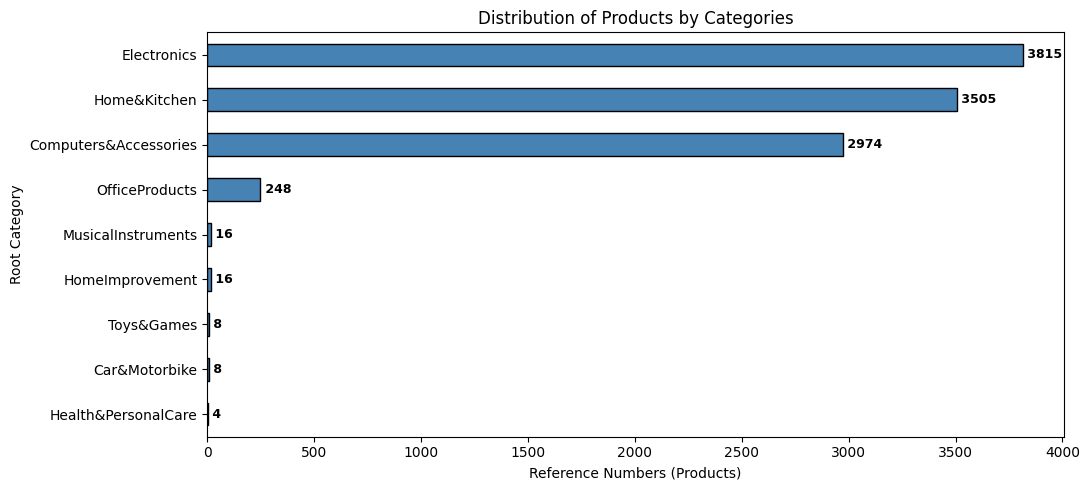

In [52]:
PlotCategoryDistribution(dfEnd)

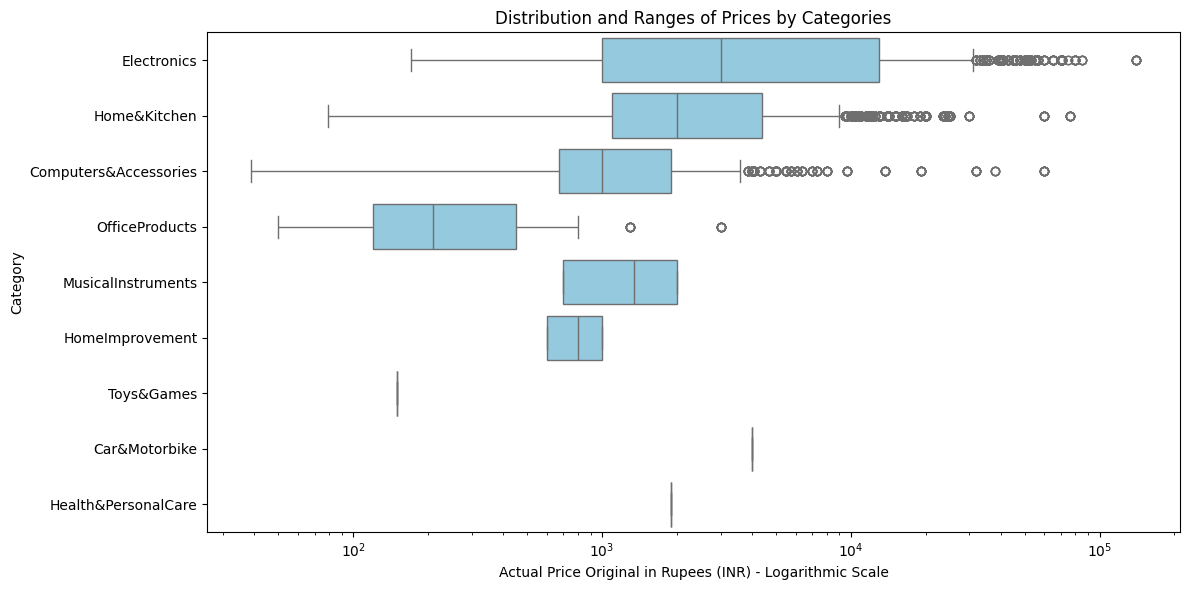

In [49]:
PlotPriceByCategoryDistribution(dfEnd, True)

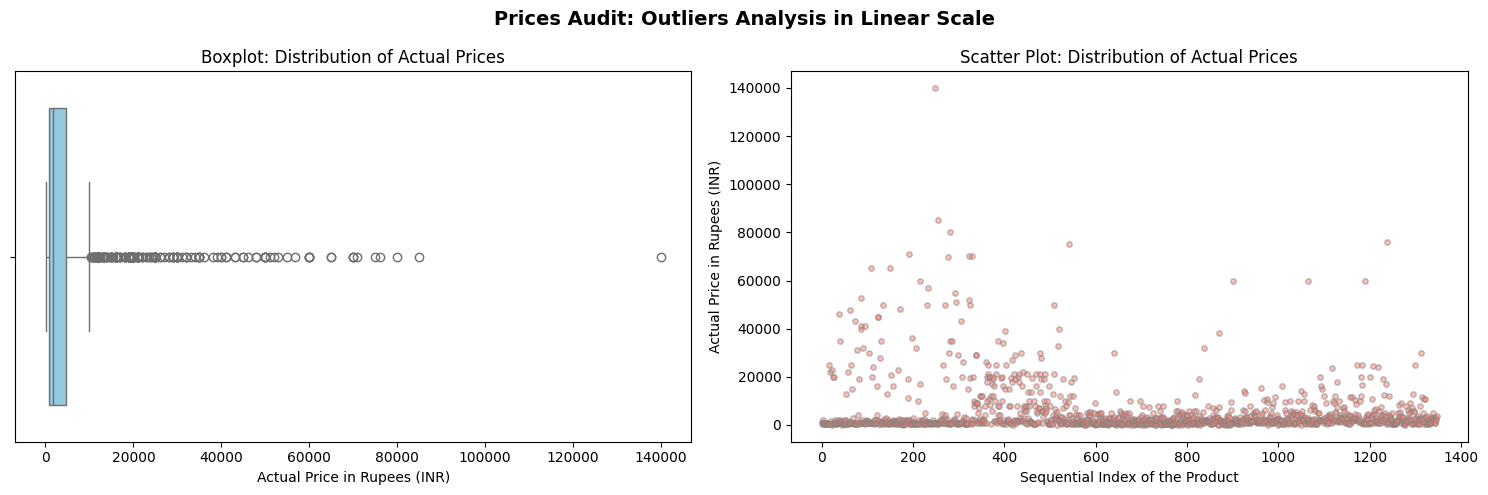

+ ======================================================================================================================================
+ Total execution time (Linear Plots)
+ --------------------------------------------------------------------------------------------------------------------------------------
0.3924 seconds
+ ======================================================================================================================================


In [53]:
PlotPriceOutliersLinear(dfEnd, True)

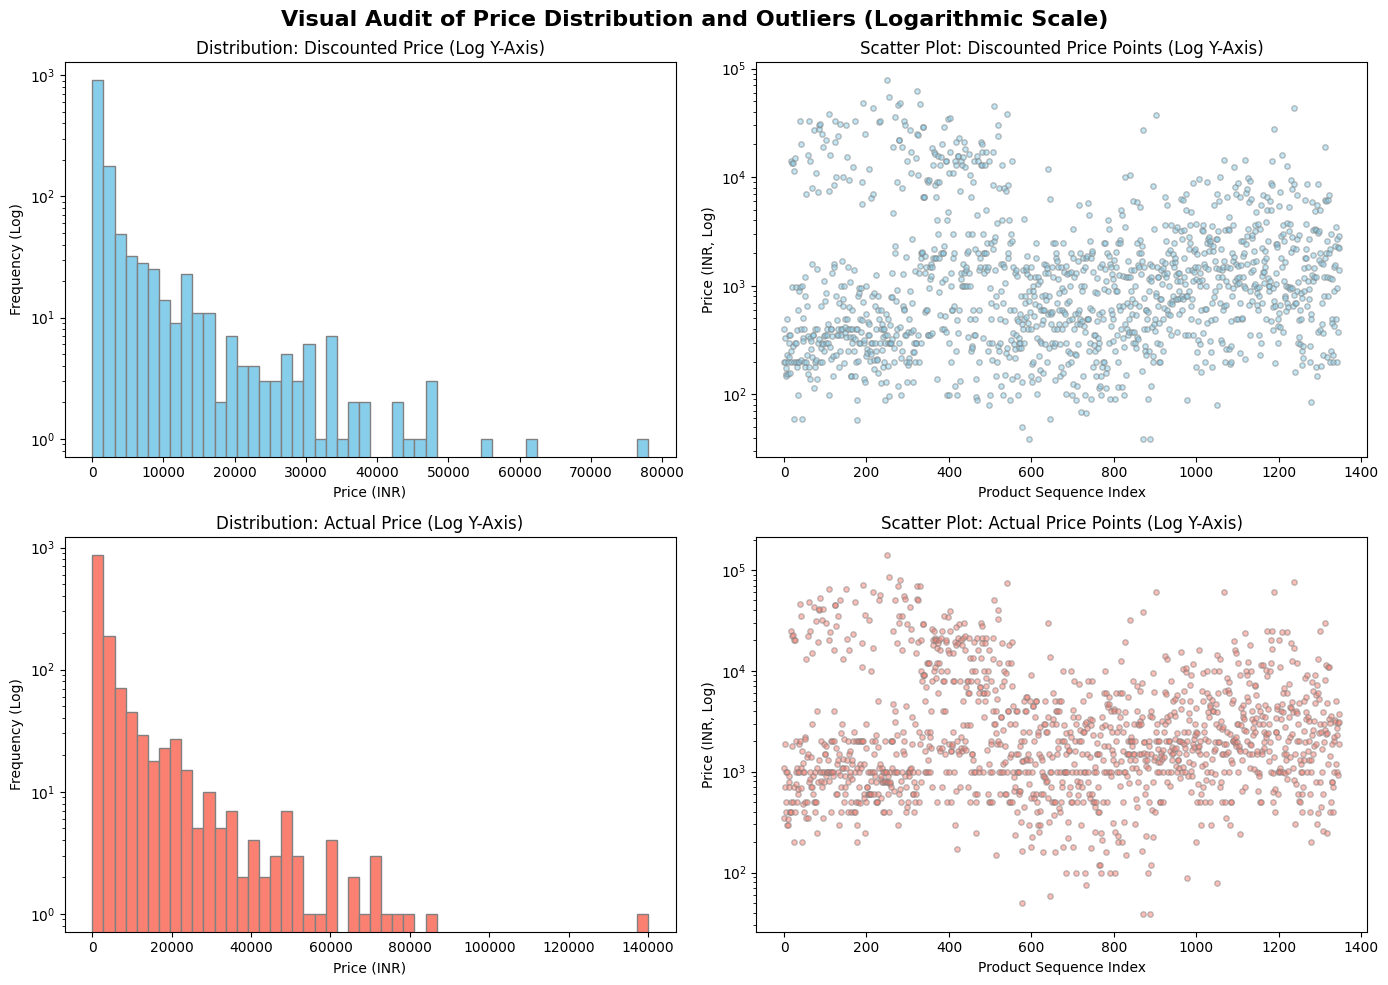

+ 
+ ======================================================================================================================================
+ Statistical Summary for Price Outliers Check
+ --------------------------------------------------------------------------------------------------------------------------------------
       discounted_price  actual_price
count           1348.00       1348.00
mean            3310.27       5700.51
std             7180.90      11229.36
min               39.00         39.00
25%              349.00        899.00
50%              899.00       1795.00
75%             2184.00       4592.50
max            77990.00     139900.00
+ 
+ Total execution time (Plot Rendering)
+ --------------------------------------------------------------------------------------------------------------------------------------
1.9019 seconds
+ ======================================================================================================================================
+ 

In [51]:
PlotPriceDistribution(dfEnd, True)

In [40]:
totEndTime = time.time()
Bra()
print(f"+ Total execution time: {totEndTime - totInitTime:.4f} seconds")
Ket()

+ --------------------------------------------------------------------------------------------------------------------------------------
+ Total execution time: 5.3014 seconds
+ ======================================================================================================================================
